Importing the Dependencies

In [7]:
!pip install matplotlib
!pip install seaborn
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.2 MB/s eta 0:00:20
   - -------------------------------------- 2.6/101.7 MB 7.1 MB/s eta 0:00:14
   - -------------------------------------- 5.0/101.7 MB 8.0 MB/s eta 0:00:13
   -- ------------------------------------- 6.8/101.7 MB 8.2 MB/s eta 0:00:12
   --- ------------------------------------ 8.9/101.7 MB 8.4 MB/s eta 0:00:11
   ---- ----------------------------------- 10.7/101.7 MB 8.6 MB/s eta 0:00:11
   ----- ---------------------------------- 12.8/101.7 MB 8.7 MB/s eta 0:00:11
   ----- ---------------------------------- 14.7/101.7 MB 8.8 MB/s eta 0:00:10
   ------ --------------------------------- 16.8/101.7 MB 8.9 MB/s eta 0:00:10
   ------- -------------------------------- 18.6/101.7 MB 8.9 MB/s eta 0:0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Importing the Booston House Price Datasets

In [15]:
house_price_dataset = pd.read_csv(r'C:\Users\admin\Downloads\house_prices_practice.csv')

In [16]:
print(house_price_dataset)

      Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  \
0      1            7       1560           0         1658       1969   
1      2            4       2827           2         1319       2012   
2      3            8       3920           0          841       2010   
3      4            5       3044           0         1058       1998   
4      5            7        801           1         2428       2020   
..   ...          ...        ...         ...          ...        ...   
295  296            1       3495           1         1792       1954   
296  297            5       3438           3         1266       2003   
297  298            6       1992           0         1148       1996   
298  299            3       3722           1         1407       1998   
299  300            9       1667           0          988       1958   

     FullBath  BedroomAbvGr  LotArea  SalePrice  
0           2             1     8059     177106  
1           3             4    1353

In [17]:
house_price_dataset.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [18]:
house_price_dataset.shape

(300, 10)

In [19]:
house_price_dataset.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

Loading Datasset in pandas Dataframe

In [20]:
house_price_dataframe = pd.DataFrame(house_price_dataset)

In [21]:
print(house_price_dataframe)

      Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  \
0      1            7       1560           0         1658       1969   
1      2            4       2827           2         1319       2012   
2      3            8       3920           0          841       2010   
3      4            5       3044           0         1058       1998   
4      5            7        801           1         2428       2020   
..   ...          ...        ...         ...          ...        ...   
295  296            1       3495           1         1792       1954   
296  297            5       3438           3         1266       2003   
297  298            6       1992           0         1148       1996   
298  299            3       3722           1         1407       1998   
299  300            9       1667           0          988       1958   

     FullBath  BedroomAbvGr  LotArea  SalePrice  
0           2             1     8059     177106  
1           3             4    1353

In [22]:
house_price_dataframe.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [23]:
house_price_dataframe.shape

(300, 10)

In [24]:
house_price_dataset.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [25]:
#Statistical measures of the datasets
house_price_dataset.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


Understanding the correlation between various features in the dataset


1.Positive Correlation

2.Negaative Correlation

In [26]:
correlation = house_price_dataset.corr()

<Axes: >

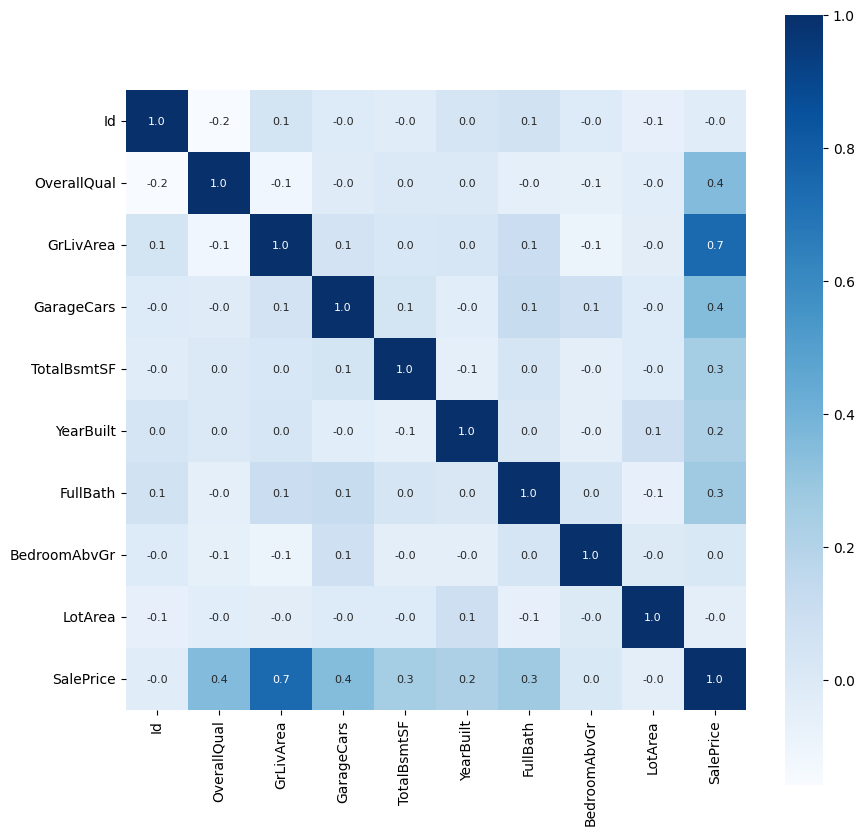

In [27]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,fmt='.1f',square=True,annot=True,annot_kws={'size':8},cmap='Blues')

Spiltting the Data and target(Price)

In [28]:
X = house_price_dataset.drop(['SalePrice'],axis=1)
Y = house_price_dataset['SalePrice']

In [29]:
print(X)
print(Y)

      Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  \
0      1            7       1560           0         1658       1969   
1      2            4       2827           2         1319       2012   
2      3            8       3920           0          841       2010   
3      4            5       3044           0         1058       1998   
4      5            7        801           1         2428       2020   
..   ...          ...        ...         ...          ...        ...   
295  296            1       3495           1         1792       1954   
296  297            5       3438           3         1266       2003   
297  298            6       1992           0         1148       1996   
298  299            3       3722           1         1407       1998   
299  300            9       1667           0          988       1958   

     FullBath  BedroomAbvGr  LotArea  
0           2             1     8059  
1           3             4    13530  
2           1     

Spiting the data into train and test

In [30]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [31]:
print(X.shape,X_train.shape,X_test.shape)

(300, 9) (240, 9) (60, 9)


Model Training

XGBoost Regressor

In [32]:
model = XGBRegressor()

In [33]:
model.fit(X_train,Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

Evaluation

In [34]:
training_data_prediction = model.predict(X_train)

In [35]:
print(training_data_prediction)

[317359.75  272769.6   341701.1   331443.22  266480.22  283052.9
 303464.12  289466.12  225010.05  192604.81  165278.88  220538.06
 405010.22  172802.64  193655.38  299313.62  213582.16  405668.8
 280272.1   326574.84  319877.97  204187.56  394318.8   173813.94
 380228.06  259985.17  136533.75  178409.62  264710.7   167666.1
 265596.75  161575.69  300917.97  147227.8   361921.38  327837.62
 144600.48  352989.72  388288.3   303343.88  220640.92  129364.195
 296239.    400258.72  204685.31  258761.67  311101.6   283099.22
 319982.75  174650.22  241604.7   337736.88  145538.73  184839.8
 343026.75  215534.11  134900.    346425.22  163556.17  213952.5
 273332.25  360606.6   381350.94  199789.08  162744.5   174716.8
 290759.16  290768.5   252495.3   294884.72  242712.17  306773.84
 319203.3   311526.38  241074.31  226984.75  211665.94  306421.12
 184625.83  189830.95  202540.75  210516.89  329907.94  161471.2
 260687.44  385174.06  190936.83  253400.83  216574.47  312456.06
 236744.06  3553

In [36]:
score_1 = metrics.r2_score(Y_train,training_data_prediction)
score_2 = metrics.mean_absolute_error(Y_train,training_data_prediction)

In [37]:
 print('R squared error : ',score_1)
 print('Mean Absolute Error : ',score_2)

R squared error :  1.0
Mean Absolute Error :  2.33203125


Visualizing the actual Price and Predicted Prices

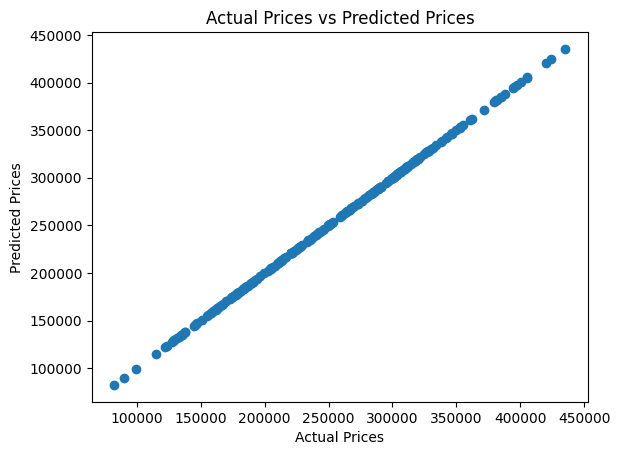

In [38]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

Prediction On test Data

In [39]:
test_data_prediction = model.predict(X_test)

In [40]:
score_1 = metrics.r2_score(Y_test,test_data_prediction)
score_2 = metrics.mean_absolute_error(Y_test,test_data_prediction)

In [41]:
 print('R squared error : ',score_1)
 print('Mean Absolute Error : ',score_2)

R squared error :  0.8342718482017517
Mean Absolute Error :  25731.025390625
